# OpsTune — Baseline evaluation

Runs **un-fine-tuned Llama 3.1 8B Instant** (Groq) on the held-out test
split and reports JSON validity, schema compliance, severity/category
accuracy, confidence MAE, and root-cause/action overlap.

This is the *before* number for the hackathon's before/after story.
After the fine-tuning run, swap the model id in the inference cell and
re-run — every metric in this notebook is computed from the cached
predictions file, so re-runs after the LLM calls are instant.

**Required env**: `GROQ_API_KEY` (free tier is fine; `OPENAI_API_KEY`
+ `OPENAI_BASE_URL` also work via the same OpenAI-compatible client).

In [1]:
from __future__ import annotations

import json
import os
import random
import sys
import time
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "finetuning").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from finetuning.eval.metrics import (
    SEVERITIES, CATEGORIES,
    score_one, aggregate, confusion, label_distribution,
)
from finetuning.generate_reports import SYSTEM_PROMPT

TEST_PATH = ROOT / "finetuning" / "splits" / "test.jsonl"
TEST_LABELED_PATH = ROOT / "finetuning" / "splits" / "test.labeled.jsonl"
PRED_DIR = ROOT / "finetuning" / "eval" / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"test.jsonl: {TEST_PATH.exists()}, test.labeled.jsonl: {TEST_LABELED_PATH.exists()}")

ROOT: /home/yacine/Code/OpsTune
test.jsonl: True, test.labeled.jsonl: True


## Configuration

Change `MODEL_ID` after fine-tuning. Everything else stays the same so
the comparison is apples-to-apples.

In [2]:
MODEL_ID = os.getenv("BASELINE_MODEL", "llama-3.1-8b-instant")
RUN_NAME = os.getenv("RUN_NAME", "baseline")
PRED_PATH = PRED_DIR / f"{RUN_NAME}.jsonl"

# Generation knobs — keep deterministic for reproducible eval
TEMPERATURE = 0.0
MAX_TOKENS = 700
MAX_WORKERS = 3      # respect Groq free-tier TPM
MAX_RETRIES = 8
BASE_BACKOFF_S = 4.0
MAX_BACKOFF_S = 75.0

print(f"model: {MODEL_ID}\nrun:   {RUN_NAME}\npredictions cache: {PRED_PATH}")

model: llama-3.1-8b-instant
run:   baseline
predictions cache: /home/yacine/Code/OpsTune/finetuning/eval/predictions/baseline.jsonl


## Load held-out test split

In [3]:
test_rows = [json.loads(l) for l in TEST_PATH.read_text(encoding="utf-8").splitlines() if l.strip()]
test_labeled = [json.loads(l) for l in TEST_LABELED_PATH.read_text(encoding="utf-8").splitlines() if l.strip()]
labeled_by_udi = {r["udi"]: r for r in test_labeled}

print(f"{len(test_rows)} test rows")
print("per-mode counts:", dict(Counter(r["metadata"]["primary_mode"] for r in test_rows)))

73 test rows
per-mode counts: {'OSF': 12, 'HDF': 17, 'RNF': 2, 'PWF': 14, None: 22, 'TWF': 6}


## Inference (cached on disk)

Each (UDI, MODEL_ID) pair is called once and appended to `predictions/<run>.jsonl`.
Re-running this cell skips UDIs that already have a cached prediction —
safe after rate-limit kills, restarts, or model swaps (use a different `RUN_NAME`).

In [4]:
from openai import OpenAI

groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
if groq_key and not openai_key:
    client = OpenAI(api_key=groq_key, base_url="https://api.groq.com/openai/v1")
elif openai_key:
    client = OpenAI(api_key=openai_key, base_url=os.getenv("OPENAI_BASE_URL"))
else:
    raise RuntimeError("Set GROQ_API_KEY or OPENAI_API_KEY")

import re
_RETRY_HINT_RE = re.compile(r"try again in ([\d.]+)s")

def predict(narrative: str) -> str:
    last_err = None
    for attempt in range(MAX_RETRIES):
        try:
            resp = client.chat.completions.create(
                model=MODEL_ID,
                temperature=TEMPERATURE,
                max_tokens=MAX_TOKENS,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": narrative},
                ],
            )
            return (resp.choices[0].message.content or "").strip()
        except Exception as exc:
            last_err = exc
            wait = min(MAX_BACKOFF_S, BASE_BACKOFF_S * (2 ** attempt)) + random.random()
            m = _RETRY_HINT_RE.search(str(exc))
            if m:
                try: wait = max(wait, float(m.group(1)) + 1.0)
                except ValueError: pass
            time.sleep(wait)
    raise RuntimeError(f"giving up after {MAX_RETRIES} attempts: {last_err}")


def already_cached(path: Path) -> set[int]:
    if not path.exists(): return set()
    seen = set()
    with path.open() as f:
        for line in f:
            try: seen.add(int(json.loads(line)["udi"]))
            except Exception: continue
    return seen

done = already_cached(PRED_PATH)
pending = [r for r in test_rows if r["metadata"]["udi"] not in done]
print(f"{len(done)} cached, {len(pending)} to call")

if pending:
    out_f = PRED_PATH.open("a", encoding="utf-8")
    completed = 0
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futures = {pool.submit(predict, r["messages"][1]["content"]): r for r in pending}
        for fut in as_completed(futures):
            row = futures[fut]
            try: raw = fut.result()
            except Exception as exc:
                raw = f"<<ERROR: {exc}>>"
            out_f.write(json.dumps({
                "udi": row["metadata"]["udi"],
                "primary_mode": row["metadata"]["primary_mode"],
                "raw": raw,
            }, ensure_ascii=False) + "\n")
            out_f.flush()
            completed += 1
            if completed % 10 == 0 or completed == len(pending):
                rate = completed / max(1e-6, time.time() - t0)
                print(f"  {completed}/{len(pending)}  ({rate:.1f} rows/s)")
    out_f.close()

print(f"predictions → {PRED_PATH}")

0 cached, 73 to call


  10/73  (0.6 rows/s)


  20/73  (0.4 rows/s)


  30/73  (0.3 rows/s)


  40/73  (0.3 rows/s)


  50/73  (0.3 rows/s)


  60/73  (0.3 rows/s)


  70/73  (0.3 rows/s)


  73/73  (0.2 rows/s)
predictions → /home/yacine/Code/OpsTune/finetuning/eval/predictions/baseline.jsonl


## Score predictions

In [5]:
preds_by_udi = {}
with PRED_PATH.open() as f:
    for line in f:
        obj = json.loads(line)
        preds_by_udi[int(obj["udi"])] = obj

scored = []
truths = []
rows_by_udi = {r["metadata"]["udi"]: r for r in test_rows}
for udi, row in rows_by_udi.items():
    truth = json.loads(row["messages"][2]["content"])
    pred_obj = preds_by_udi.get(udi)
    raw = pred_obj["raw"] if pred_obj else ""
    s = score_one(raw, truth)
    s["udi"] = udi
    s["primary_mode"] = row["metadata"]["primary_mode"]
    s["narrative"] = row["messages"][1]["content"]
    s["truth"] = truth
    s["raw"] = raw
    scored.append(s)
    truths.append(truth)

agg = aggregate(scored)
pd.DataFrame({"metric": list(agg.keys()), "value": list(agg.values())})

,metric,value
0,n,73.000000
1,json_valid_rate,1.000000
2,schema_ok_rate,0.986301
3,severity_accuracy,0.547945
4,severity_mean_dist,0.520548
5,category_accuracy,0.452055
6,confidence_mae,0.256164
7,causes_jaccard_mean,0.019023
8,actions_jaccard_mean,0.044461


## Severity & category confusion


severity confusion (off-vocab predictions excluded):
               pred:low  pred:medium  pred:high  pred:critical
true:low             22            1          1              0
true:medium           0            3          6              0
true:high             0           16         14              1
true:critical         0            4          4              1


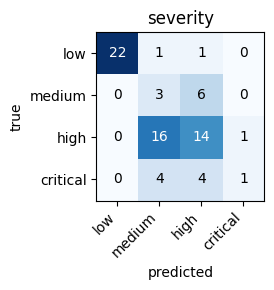


category confusion (off-vocab predictions excluded):
                 pred:mechanical  pred:electrical  pred:thermal  pred:sensor  pred:process  pred:quality  pred:safety  pred:unknown
true:mechanical               16                0             1            0             1             0            0             0
true:electrical               11                0             1            0             1             1            0             0
true:thermal                  14                0             2            0             0             0            0             0
true:sensor                    0                0             0            0             0             0            0             0
true:process                   0                0             0            0             0             0            0             0
true:quality                   0                0             0            0             0             0            0             0
true:safety           

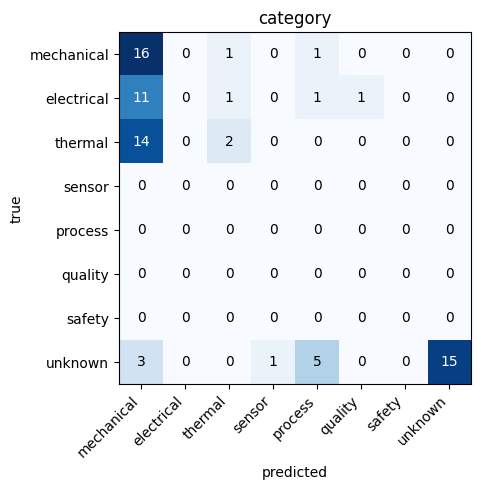


predicted-severity distribution: {'high': 25, 'medium': 24, 'critical': 2, 'low': 22}
predicted-category distribution: {'mechanical': 44, 'unknown': 15, 'thermal': 4, 'quality': 1, 'process': 7, 'mechanical|thermal|safety': 1, 'sensor': 1}


In [6]:
def show_confusion(field, labels):
    mat = confusion(scored, truths, field, labels)
    df = pd.DataFrame(mat, index=[f"true:{l}" for l in labels], columns=[f"pred:{l}" for l in labels])
    print(f"\n{field} confusion (off-vocab predictions excluded):")
    print(df.to_string())
    fig, ax = plt.subplots(figsize=(1.0 + 0.6*len(labels), 1.0 + 0.5*len(labels)))
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(field)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, mat[i][j], ha="center", va="center",
                    color="white" if mat[i][j] > max(max(r) for r in mat)/2 else "black")
    plt.tight_layout(); plt.show()

show_confusion("severity", SEVERITIES)
show_confusion("category", CATEGORIES)

print("\npredicted-severity distribution:", dict(label_distribution(scored, "severity")))
print("predicted-category distribution:", dict(label_distribution(scored, "category")))

## Per-mode breakdown

Where does the base model do best/worst? Big spreads here are the
headline before/after story for the demo.

In [7]:
df_scored = pd.DataFrame(scored)
by_mode = (df_scored.assign(primary_mode=lambda d: d["primary_mode"].fillna("HEALTHY"))
                     .groupby("primary_mode")
                     .agg(n=("udi","count"),
                          json_valid=("json_valid","mean"),
                          schema_ok=("schema_ok","mean"),
                          severity_acc=("severity_match","mean"),
                          category_acc=("category_match","mean"),
                          conf_mae=("confidence_mae","mean"),
                          causes_jaccard=("causes_jaccard","mean"),
                          actions_jaccard=("actions_jaccard","mean"))
                     .round(3))
by_mode

,n,json_valid,schema_ok,severity_acc,category_acc,conf_mae,causes_jaccard,actions_jaccard
primary_mode,,,,,,,,
HDF,17,1.0,0.941,0.471,0.118,0.303,0.021,0.066
HEALTHY,22,1.0,1.000,1.000,0.682,0.265,0.000,0.000
OSF,12,1.0,1.000,0.083,0.833,0.213,0.058,0.068
PWF,14,1.0,1.000,0.429,0.000,0.269,0.021,0.053
RNF,2,1.0,1.000,0.000,0.000,0.350,0.000,0.061
TWF,6,1.0,1.000,0.500,1.000,0.113,0.007,0.075


## Spot-check predictions

In [8]:
def show_example(s):
    print(f"--- UDI={s['udi']} primary={s['primary_mode']} ---")
    print(f"narrative: {s['narrative']}\n")
    print(f"raw model output:\n{s['raw'][:800]}{'...' if len(s['raw'])>800 else ''}\n")
    print(f"json_valid={s['json_valid']} schema_ok={s['schema_ok']}")
    if s['schema_issues']:
        print(f"  issues: {s['schema_issues']}")
    print(f"severity:  pred={(s['predicted'] or {}).get('severity')!r:>10}  true={s['truth']['severity']!r}")
    print(f"category:  pred={(s['predicted'] or {}).get('category')!r:>10}  true={s['truth']['category']!r}")
    print(f"confidence MAE: {s['confidence_mae']}")
    print(f"causes Jaccard:  {s['causes_jaccard']}")
    print(f"actions Jaccard: {s['actions_jaccard']}\n")

valid = [s for s in scored if s["json_valid"]]
if valid:
    valid_sorted = sorted(valid, key=lambda s: ((s.get("causes_jaccard") or 0) + (s.get("actions_jaccard") or 0)))
    print("### WORST (lowest causes+actions overlap)")
    show_example(valid_sorted[0])
    print("### BEST (highest overlap)")
    show_example(valid_sorted[-1])
broken = [s for s in scored if not s["json_valid"]]
if broken:
    print("### BROKEN JSON example")
    show_example(broken[0])

### WORST (lowest causes+actions overlap)
--- UDI=2713 primary=None ---
narrative: Just had to do another pointless walk around to make sure the line is still somehow magically healthy. Everything looks good, no issues to report, just a waste of time at this point since we've been running clean all day.

raw model output:
{
  "severity": "low",
  "category": "unknown",
  "likely_root_causes": [],
  "evidence": ["walk around", "no issues reported", "line has been running clean all day"],
  "recommended_actions": [],
  "confidence": 0.0,
  "final_report": "Routine walk around yielded no issues, but the process may be overly cautious given the line's clean operation."
}

json_valid=True schema_ok=True
severity:  pred=     'low'  true='low'
category:  pred= 'unknown'  true='unknown'
confidence MAE: 0.86
causes Jaccard:  0.0
actions Jaccard: 0.0

### BEST (highest overlap)
--- UDI=1096 primary=PWF ---
narrative: Hey, line 3 just went down, looks like something went wrong with the tool. I wa

## Save run summary

Persists the headline numbers so the fine-tuned run can be diffed against
this baseline without re-running anything.

In [9]:
summary = {
    "run_name": RUN_NAME,
    "model": MODEL_ID,
    "n_test": len(test_rows),
    "aggregate": agg,
    "by_mode": by_mode.reset_index().to_dict(orient="records"),
    "predicted_severity_distribution": dict(label_distribution(scored, "severity")),
    "predicted_category_distribution": dict(label_distribution(scored, "category")),
}
summary_path = PRED_DIR / f"{RUN_NAME}.summary.json"
summary_path.write_text(json.dumps(summary, indent=2, default=str))
print(f"summary → {summary_path}")

summary → /home/yacine/Code/OpsTune/finetuning/eval/predictions/baseline.summary.json
